In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [25]:
K = 3
STRATEGY = "uniform"
FUSION_TYPE = "attention"   # later you can use "attention"

K_FRAME_PATH = Path(f"../data/k_frames/K{K}_{STRATEGY}.csv")
NORMALIZATION_PATH = Path("../data/processed/normalization_stats.json")

df = pd.read_csv(K_FRAME_PATH)

print(df.head())
print(df.columns)
print(df.groupby(["split", "class_name"]).size())

  split  site_id class_name  label  K strategy  selected_frame_count  \
0  test       26     looted      1  3  uniform                     3   
1  test       27     looted      1  3  uniform                     3   
2  test       29     looted      1  3  uniform                     3   
3  test       30     looted      1  3  uniform                     3   
4  test       31     looted      1  3  uniform                     3   

   frame_1_index frame_1_name                                    frame_1_path  \
0              0  2016_01.jpg  ..\data\processed_images\looted\26\2016_01.jpg   
1              0  2016_01.jpg  ..\data\processed_images\looted\27\2016_01.jpg   
2              0  2016_01.jpg  ..\data\processed_images\looted\29\2016_01.jpg   
3              0  2016_01.jpg  ..\data\processed_images\looted\30\2016_01.jpg   
4              0  2016_01.jpg  ..\data\processed_images\looted\31\2016_01.jpg   

   frame_2_index frame_2_name                                    frame_2_path  \

In [26]:
with open(NORMALIZATION_PATH, "r") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std = norm_stats["std"]

print("Mean:", mean)
print("Std:", std)

Mean: [0.6641249441448802, 0.5746265725068144, 0.42835551291561075]
Std: [0.17935859533908458, 0.1680383227926673, 0.17305869328805765]


In [27]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val_1"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("Train class counts:")
print(train_df["label"].value_counts())

print("Validation class counts:")
print(val_df["label"].value_counts())

print("Test class counts:")
print(test_df["label"].value_counts())

Train: 524
Val: 18
Test: 61
Train class counts:
label
0    460
1     64
Name: count, dtype: int64
Validation class counts:
label
1    9
0    9
Name: count, dtype: int64
Test class counts:
label
0    35
1    26
Name: count, dtype: int64


In [28]:
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [29]:
class KFrameDataset(Dataset):
    def __init__(self, dataframe, k, transform=None):
        self.df = dataframe
        self.k = k
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        frames = []

        for i in range(1, self.k + 1):
            img_path = row[f"frame_{i}_path"]
            img = Image.open(img_path).convert("RGB")

            if self.transform:
                img = self.transform(img)

            frames.append(img)

        # shape: [K, 3, 224, 224]
        frames = torch.stack(frames, dim=0)

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        return frames, label

In [30]:
BATCH_SIZE = 8

train_dataset = KFrameDataset(train_df, k=K, transform=image_transform)
val_dataset = KFrameDataset(val_df, k=K, transform=image_transform)
test_dataset = KFrameDataset(test_df, k=K, transform=image_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 66
Val batches: 3
Test batches: 8


In [31]:
frames, labels = next(iter(train_loader))

print(frames.shape)
print(labels.shape)

torch.Size([8, 3, 3, 224, 224])
torch.Size([8])


In [32]:
class CNN_GRU_Model(nn.Module):
    def __init__(self, num_classes=2, feature_dim=128, hidden_dim=128, num_layers=1):
        super(CNN_GRU_Model, self).__init__()

        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim

        # CNN encoder for each frame
        self.cnn_encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(64, feature_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.AdaptiveAvgPool2d((1, 1))  # [B*K, feature_dim, 1, 1]
        )

        # GRU temporal fusion
        self.gru = nn.GRU(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: [B, K, 3, 224, 224]
        batch_size, k, c, h, w = x.shape

        # combine batch and time
        x = x.reshape(batch_size * k, c, h, w)

        # CNN features
        features = self.cnn_encoder(x)

        # [B*K, feature_dim]
        features = features.reshape(batch_size, k, self.feature_dim)

        # GRU output
        gru_out, hidden = self.gru(features)

        # use last time-step output
        final_feature = gru_out[:, -1, :]

        output = self.classifier(final_feature)

        return output

In [33]:
class CNN_Attention_Model(nn.Module):
    def __init__(self, num_classes=2, feature_dim=128):
        super(CNN_Attention_Model, self).__init__()

        self.feature_dim = feature_dim

        self.cnn_encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, feature_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        # attention score for each frame feature
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: [B, K, 3, 224, 224]
        batch_size, k, c, h, w = x.shape

        x = x.reshape(batch_size * k, c, h, w)

        features = self.cnn_encoder(x)
        features = features.reshape(batch_size, k, self.feature_dim)

        # attention scores: [B, K, 1]
        scores = self.attention(features)

        # attention weights: [B, K, 1]
        weights = torch.softmax(scores, dim=1)

        # weighted feature: [B, feature_dim]
        fused_feature = torch.sum(features * weights, dim=1)

        output = self.classifier(fused_feature)

        return output

In [34]:
model = CNN_Attention_Model(
    num_classes=2,
    feature_dim=128
).to(device)

In [35]:
model = CNN_Attention_Model(
    num_classes=2,
    feature_dim=128
).to(device)

In [36]:
class_counts = train_df["label"].value_counts().sort_index()
print(class_counts)

num_preserved = class_counts[0]
num_looted = class_counts[1]

total = num_preserved + num_looted

weight_preserved = total / (2 * num_preserved)
weight_looted = total / (2 * num_looted)

class_weights = torch.tensor(
    [weight_preserved, weight_looted],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

label
0    460
1     64
Name: count, dtype: int64
Class weights: tensor([0.5696, 4.0938])


In [37]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [38]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for frames, labels in tqdm(dataloader):
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(frames)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * frames.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [39]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for frames, labels in tqdm(dataloader):
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * frames.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = None

    cm = confusion_matrix(all_labels, all_preds)

    metrics = {
        "loss": epoch_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }

    return metrics

In [40]:
EPOCHS = 10

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

experiment_name = f"light_temporal_fusion_K{K}_{FUSION_TYPE}"

best_val_f1 = 0.0
best_model_path = RESULTS_DIR / f"{experiment_name}_best.pth"

history = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_metrics = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']}"
    )

    history.append({
        "epoch": epoch + 1,
        "K": K,
        "fusion_type": FUSION_TYPE,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    })

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved ✅")


Epoch 1/10


100%|██████████| 3/3 [00:00<00:00,  5.05it/s]


Train Loss: 0.6231 | Train Acc: 0.8511
Val Loss: 0.5955 | Val Acc: 0.6111 | Val Precision: 0.5625 | Val Recall: 1.0000 | Val F1: 0.7200 | Val AUC: 0.617283950617284
Best model saved ✅

Epoch 2/10


100%|██████████| 3/3 [00:00<00:00,  5.44it/s]


Train Loss: 0.5528 | Train Acc: 0.8187
Val Loss: 1.5477 | Val Acc: 0.5000 | Val Precision: 0.5000 | Val Recall: 0.2222 | Val F1: 0.3077 | Val AUC: 0.43209876543209874

Epoch 3/10


...

Train Loss: 0.3980 | Train Acc: 0.8454
Val Loss: 1.3842 | Val Acc: 0.3889 | Val Precision: 0.4000 | Val Recall: 0.4444 | Val F1: 0.4211 | Val AUC: 0.5432098765432098

Epoch 9/10


100%|██████████| 3/3 [00:00<00:00,  5.56it/s]


Train Loss: 0.3617 | Train Acc: 0.8760
Val Loss: 0.6895 | Val Acc: 0.6111 | Val Precision: 0.5714 | Val Recall: 0.8889 | Val F1: 0.6957 | Val AUC: 0.617283950617284

Epoch 10/10


100%|██████████| 3/3 [00:00<00:00,  5.61it/s]

Train Loss: 0.4493 | Train Acc: 0.8378
Val Loss: 1.3149 | Val Acc: 0.4444 | Val Precision: 0.4444 | Val Recall: 0.4444 | Val F1: 0.4444 | Val AUC: 0.46913580246913583


In [41]:
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / f"{experiment_name}_history.csv", index=False)

history_df

,epoch,K,fusion_type,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,1,3,attention,0.623107,0.851145,0.595454,0.611111,0.562500,1.000000,0.720000,0.617284
1,2,3,attention,0.552811,0.818702,1.547732,0.500000,0.500000,0.222222,0.307692,0.432099
2,3,3,attention,0.435786,0.856870,1.850067,0.388889,0.333333,0.222222,0.266667,0.432099
3,4,3,attention,0.464228,0.874046,1.601357,0.500000,0.500000,0.444444,0.470588,0.407407
4,5,3,attention,0.394051,0.874046,0.971348,0.555556,0.538462,0.777778,0.636364,0.543210
5,6,3,attention,0.439329,0.856870,1.060957,0.388889,0.400000,0.444444,0.421053,0.604938
6,7,3,attention,0.387538,0.896947,0.805260,0.611111,0.571429,0.888889,0.695652,0.604938
7,8,3,attention,0.398003,0.845420,1.384200,0.388889,0.400000,0.444444,0.421053,0.543210
8,9,3,attention,0.361719,0.875954,0.689451,0.611111,0.571429,0.888889,0.695652,0.617284
9,10,3,attention,0.449273,0.837786,1.314879,0.444444,0.444444,0.444444,0.444444,0.469136


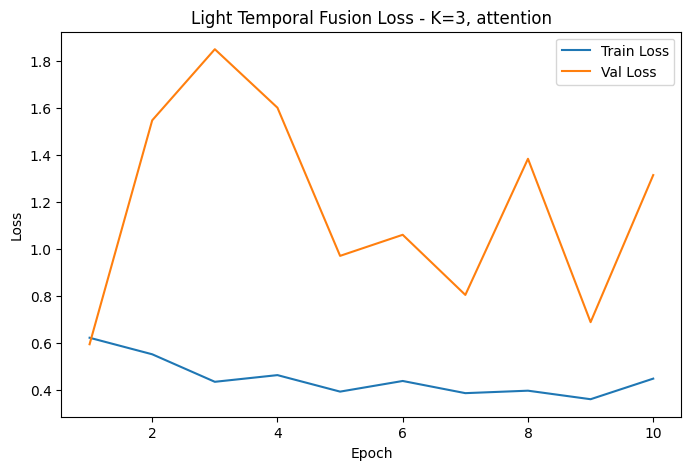

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Light Temporal Fusion Loss - K={K}, {FUSION_TYPE}")
plt.legend()
plt.show()

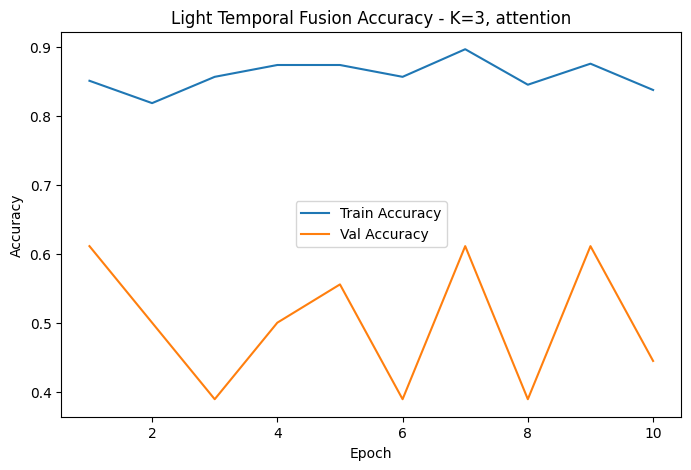

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Light Temporal Fusion Accuracy - K={K}, {FUSION_TYPE}")
plt.legend()
plt.show()

In [45]:
for file in RESULTS_DIR.glob("*best.pth"):
    print(file.name)

light_temporal_fusion_K3_attention_best.pth
light_temporal_fusion_K3_gru_best.pth
single_frame_cnn_best.pth
temporal_pooling_K3_mean_best.pth
temporal_pooling_K5_mean_best.pth
temporal_pooling_K8_mean_best.pth
two_frame_change_cnn_best.pth


In [47]:
K = 3
FUSION_TYPE = "attention"

RESULTS_DIR = Path("../results")
best_model_path = RESULTS_DIR / f"light_temporal_fusion_K{K}_{FUSION_TYPE}_best.pth"

print("Loading:", best_model_path)

best_model = CNN_Attention_Model(
    num_classes=2,
    feature_dim=128
).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_metrics = evaluate(best_model, test_loader, criterion, device)

print("Test Results:")
print("Accuracy:", test_metrics["accuracy"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1:", test_metrics["f1"])
print("AUC:", test_metrics["auc"])
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

Loading: ..\results\light_temporal_fusion_K3_attention_best.pth


100%|██████████| 8/8 [00:02<00:00,  2.95it/s]

Test Results:
Accuracy: 0.4426229508196721
Precision: 0.43103448275862066
Recall: 0.9615384615384616
F1: 0.5952380952380952
AUC: 0.7043956043956043
Confusion Matrix:
[[ 2 33]
 [ 1 25]]


In [48]:
test_result_df = pd.DataFrame([{
    "model": "cnn_gru_light_temporal_fusion",
    "K": K,
    "strategy": STRATEGY,
    "fusion_type": FUSION_TYPE,
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

test_result_df.to_csv(
    RESULTS_DIR / f"{experiment_name}_test_results.csv",
    index=False
)

test_result_df

,model,K,strategy,fusion_type,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,cnn_gru_light_temporal_fusion,3,uniform,attention,0.442623,0.431034,0.961538,0.595238,0.704396


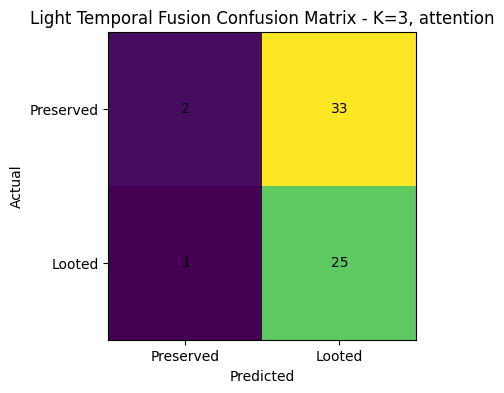

In [49]:
cm = test_metrics["confusion_matrix"]

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Light Temporal Fusion Confusion Matrix - K={K}, {FUSION_TYPE}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Preserved", "Looted"])
plt.yticks([0, 1], ["Preserved", "Looted"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()